In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abhishek14398/salary-dataset-simple-linear-regression")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'salary-dataset-simple-linear-regression' dataset.
Path to dataset files: /kaggle/input/salary-dataset-simple-linear-regression


In [ ]:
import os

new_data_files = os.listdir(path)
print(new_data_files)

['Salary_dataset.csv']


In [ ]:
df_salary = pd.read_csv(os.path.join(path, 'Salary_dataset.csv'))
display(df_salary.head())

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [ ]:
#We will check if data is clean or not :

#Missing Value:
df_salary.isnull().sum()

#Duplicate rows:
df_salary.duplicated().sum()

#Wrong data type:
df_salary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


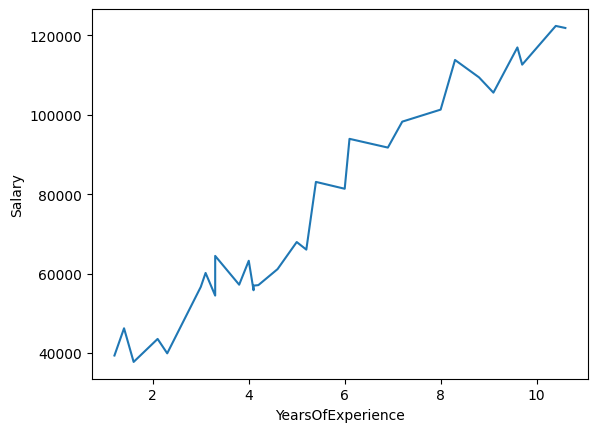

In [ ]:
x =df_salary['YearsExperience']
y=df_salary['Salary']
plt.xlabel('YearsOfExperience')
plt.ylabel('Salary')
plt.plot(x,y)
plt.show()

In [55]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [56]:
print(x_train.shape)
print(x_test.shape)
print("Here it mean that our data has been spilit for training and testing")
print(y_train.shape)
print(y_test.shape)

(24,)
(6,)
Here it mean that our data has been spilit for training and testing
(24,)
(6,)


In [60]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train.values.reshape(-1,1),y_train)

LinearRegression()

In [64]:
print("W =",model.coef_)
print("b =",model.intercept_)

W = [9423.81532303]
b = 24380.201479473704


In [73]:
prediction=model.predict([[8]])
print(prediction)

[99770.72406372]


In [83]:
from sklearn.metrics import mean_squared_error,r2_score
y_pred=model.predict(x_test.values.reshape(-1,1))
mse=mean_squared_error(y_test,y_pred)

print("Mean Squared Error:",mse)
print("R2 Score:",r2_score(y_test,y_pred))

Mean Squared Error: 49830096.855908394
R2 Score: 0.9024461774180497


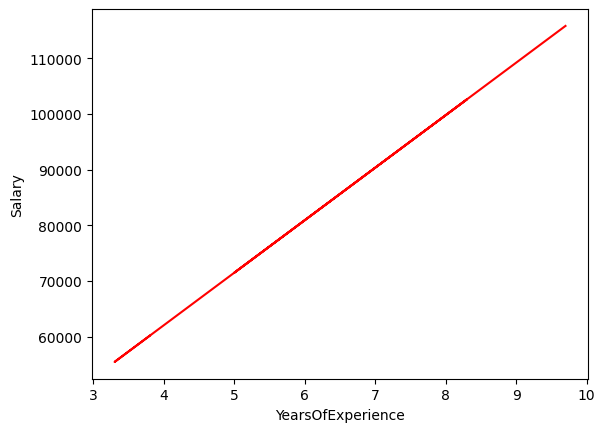

In [89]:
plt.plot(x_test,y_pred,color='red')
plt.xlabel('YearsOfExperience')
plt.ylabel('Salary')
plt.show()